# 실험: 스마트 물류창고 지연 예측 - 모델링 전 분석

목표:
- 모델 학습 전에 데이터 구조와 품질을 먼저 이해한다.
- 재현 가능한 전처리 및 피처 엔지니어링 흐름을 만든다.
- 모델 학습 직전 단계의 `train_model_input`, `test_model_input`를 만든다.
- 타깃 누수 가능성을 명시적으로 관리하면서 이후 검증 단계로 넘긴다.


In [35]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-smart-storage')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

TARGET_COL = 'avg_delay_minutes_next_30m'
ID_COL = 'ID'
LAYOUT_KEY = 'layout_id'
GROUP_COL = 'scenario_id'


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() or ((candidate / 'data').exists() and (candidate / 'pyproject.toml').exists()):
            return candidate
    raise FileNotFoundError('Could not locate repo root from current working directory.')


def safe_divide(numerator, denominator):
    if isinstance(denominator, pd.Series):
        denominator = denominator.replace(0, np.nan)
    elif denominator == 0:
        denominator = np.nan
    return numerator / denominator


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data'
REPO_ROOT


PosixPath('/home/park/project/smart-storage')

## 작업 순서

1. 원천 테이블을 불러오고 train/test 입력 컬럼 정합성을 확인한다.
2. `layout_info`를 안전하게 조인하고 커버리지와 구조를 점검한다.
3. 결측치, 범위 위반, 이상치, 상수 컬럼, train/test shift를 진단한다.
4. 전처리 정책을 정리하고 누수 없는 파생 피처를 만든다.
5. 최종 모델 입력 테이블과 보조 산출물을 고정한다.


In [19]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
layout_info = pd.read_csv(DATA_DIR / 'layout_info.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')



In [20]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 94 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          250000 non-null  str    
 1   layout_id                   250000 non-null  str    
 2   scenario_id                 250000 non-null  str    
 3   order_inflow_15m            220436 non-null  float64
 4   unique_sku_15m              220076 non-null  float64
 5   avg_items_per_order         220377 non-null  float64
 6   urgent_order_ratio          220246 non-null  float64
 7   heavy_item_ratio            220384 non-null  float64
 8   cold_chain_ratio            220549 non-null  float64
 9   sku_concentration           220301 non-null  float64
 10  robot_active                250000 non-null  int64  
 11  robot_idle                  250000 non-null  int64  
 12  robot_charging              250000 non-null  int64  
 13  robot_utilization        

In [21]:
train_feature_cols = [col for col in train.columns if col != TARGET_COL]
test_feature_cols = list(test.columns)

missing_from_test = sorted(set(train_feature_cols) - set(test_feature_cols))
extra_in_test = sorted(set(test_feature_cols) - set(train_feature_cols))
assert not missing_from_test, f'Columns missing from test: {missing_from_test}'
assert not extra_in_test, f'Unexpected extra columns in test: {extra_in_test}'

layout_feature_cols = [col for col in layout_info.columns if col != LAYOUT_KEY]
meta_cols = [ID_COL, LAYOUT_KEY, GROUP_COL]
categorical_candidates = [LAYOUT_KEY, 'day_of_week', 'shift_hour']
numeric_feature_candidates = [
    col for col in train_feature_cols
    if col not in meta_cols and pd.api.types.is_numeric_dtype(train[col])
]

column_role_summary = pd.DataFrame(
    [
        {'role': 'id_only', 'columns': ID_COL},
        {'role': 'group_only', 'columns': GROUP_COL},
        {'role': 'layout_join_key', 'columns': LAYOUT_KEY},
        {'role': 'target', 'columns': TARGET_COL},
        {'role': 'categorical_candidates', 'columns': ', '.join(categorical_candidates)},
        {'role': 'layout_static_columns', 'columns': ', '.join(layout_feature_cols)},
        {'role': 'numeric_feature_count', 'columns': str(len(numeric_feature_candidates))},
    ]
)

key_cardinality = pd.Series(
    {
        'layout_id_unique_train': train[LAYOUT_KEY].nunique(dropna=True),
        'layout_id_unique_test': test[LAYOUT_KEY].nunique(dropna=True),
        'scenario_id_unique_train': train[GROUP_COL].nunique(dropna=True),
        'scenario_id_unique_test': test[GROUP_COL].nunique(dropna=True),
        'day_of_week_unique_train': train['day_of_week'].nunique(dropna=True),
        'shift_hour_unique_train': train['shift_hour'].nunique(dropna=True),
        'layout_type_unique': layout_info['layout_type'].nunique(dropna=True),
    },
    name='unique_count',
)

column_role_summary


,role,columns
0,id_only,ID
1,group_only,scenario_id
2,layout_join_key,layout_id
3,target,avg_delay_minutes_next_30m
4,categorical_candidates,"layout_id, day_of_week, shift_hour"
5,layout_static_columns,"layout_type, aisle_width_avg, intersection_cou..."
6,numeric_feature_count,90


In [22]:
key_cardinality


layout_id_unique_train        250
layout_id_unique_test         100
scenario_id_unique_train    10000
scenario_id_unique_test      2000
day_of_week_unique_train        7
shift_hour_unique_train        24
layout_type_unique              4
Name: unique_count, dtype: int64

## 진단 함수

이 구간의 함수들은 모델을 학습하지 않고도 데이터 상태를 점검하기 위한 도구들입니다.
결측치, 이상치, 허용 범위 위반, 상수 컬럼, train/test 분포 차이를 진단하는 데 사용합니다.


In [23]:
def compute_psi(train_s: pd.Series, test_s: pd.Series, bins: int = 10) -> float:
    train_s = pd.to_numeric(train_s, errors='coerce').dropna()
    test_s = pd.to_numeric(test_s, errors='coerce').dropna()
    if train_s.empty or test_s.empty or train_s.nunique() < 5:
        return np.nan

    quantiles = np.unique(np.nanquantile(train_s, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        return np.nan

    bucket_edges = quantiles.astype(float).copy()
    bucket_edges[0] = -np.inf
    bucket_edges[-1] = np.inf

    train_bins = pd.cut(train_s, bucket_edges, include_lowest=True)
    test_bins = pd.cut(test_s, bucket_edges, include_lowest=True)

    aligned = pd.concat(
        [
            train_bins.value_counts(normalize=True, sort=False),
            test_bins.value_counts(normalize=True, sort=False),
        ],
        axis=1,
    ).fillna(0.0)
    aligned.columns = ['train_pct', 'test_pct']

    epsilon = 1e-6
    train_pct = aligned['train_pct'].clip(lower=epsilon)
    test_pct = aligned['test_pct'].clip(lower=epsilon)
    return float(((train_pct - test_pct) * np.log(train_pct / test_pct)).sum())


def summarize_missing(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        rows.append(
            {
                'column': col,
                'train_missing_rate': train_df[col].isna().mean() if col in train_df.columns else np.nan,
                'test_missing_rate': test_df[col].isna().mean() if col in test_df.columns else np.nan,
                'missing_rate_gap': (
                    abs(train_df[col].isna().mean() - test_df[col].isna().mean())
                    if col in train_df.columns and col in test_df.columns
                    else np.nan
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(['train_missing_rate', 'missing_rate_gap'], ascending=False)


def build_constant_report(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        series = df[col]
        value_share = series.value_counts(dropna=False, normalize=True)
        top_share = float(value_share.iloc[0]) if not value_share.empty else np.nan
        nunique = int(series.nunique(dropna=True))
        rows.append(
            {
                'column': col,
                'nunique_non_null': nunique,
                'top_value_share': top_share,
                'is_constant': nunique <= 1,
                'is_near_constant': top_share >= 0.995 if pd.notna(top_share) else False,
            }
        )
    return pd.DataFrame(rows).sort_values(['is_constant', 'is_near_constant', 'top_value_share'], ascending=False)


def propose_bounds(column: str):
    bounded_zero_one = {
        'daily_forecast_accuracy',
        'pack_utilization',
        'loading_dock_util',
        'express_lane_util',
        'staging_area_util',
        'vertical_utilization',
        'agv_task_success_rate',
        'barcode_read_success_rate',
    }
    if column.endswith('_pct'):
        return (0.0, 100.0)
    if column.endswith('_ratio') or column.endswith('_util') or column.endswith('_utilization') or column.endswith('_success_rate'):
        return (0.0, 1.0)
    if column in bounded_zero_one:
        return (0.0, 1.0)
    return None


def build_range_violation_report(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        bounds = propose_bounds(col)
        if bounds is None:
            continue
        lower, upper = bounds
        train_s = pd.to_numeric(train_df[col], errors='coerce')
        test_s = pd.to_numeric(test_df[col], errors='coerce')
        train_mask = train_s.notna()
        test_mask = test_s.notna()
        train_rate = ((train_s[train_mask] < lower) | (train_s[train_mask] > upper)).mean() if train_mask.any() else np.nan
        test_rate = ((test_s[test_mask] < lower) | (test_s[test_mask] > upper)).mean() if test_mask.any() else np.nan
        rows.append(
            {
                'column': col,
                'expected_bounds': f'[{lower}, {upper}]',
                'train_out_of_bounds_rate': train_rate,
                'test_out_of_bounds_rate': test_rate,
            }
        )
    if not rows:
        return pd.DataFrame(columns=['column', 'expected_bounds', 'train_out_of_bounds_rate', 'test_out_of_bounds_rate'])
    return pd.DataFrame(rows).sort_values(['train_out_of_bounds_rate', 'test_out_of_bounds_rate'], ascending=False)


def build_outlier_report(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        if series.empty:
            continue

        q1, q3 = series.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr > 0:
            lower_iqr = q1 - 1.5 * iqr
            upper_iqr = q3 + 1.5 * iqr
            pct_outside_iqr = ((series < lower_iqr) | (series > upper_iqr)).mean()
        else:
            lower_iqr = np.nan
            upper_iqr = np.nan
            pct_outside_iqr = 0.0

        median = series.median()
        mad = (series - median).abs().median()
        if mad > 0:
            robust_z = 0.6745 * (series - median) / mad
            pct_robust_gt4 = (robust_z.abs() > 4).mean()
        else:
            pct_robust_gt4 = np.nan

        rows.append(
            {
                'column': col,
                'p01': series.quantile(0.01),
                'p50': median,
                'p99': series.quantile(0.99),
                'pct_outside_iqr': pct_outside_iqr,
                'pct_robust_z_gt4': pct_robust_gt4,
                'lower_iqr_bound': lower_iqr,
                'upper_iqr_bound': upper_iqr,
                'clipping_candidate': bool((pct_outside_iqr > 0.01) and (series.nunique() > 20)),
            }
        )
    if not rows:
        return pd.DataFrame(columns=['column', 'p01', 'p50', 'p99', 'pct_outside_iqr', 'pct_robust_z_gt4', 'lower_iqr_bound', 'upper_iqr_bound', 'clipping_candidate'])
    return pd.DataFrame(rows).sort_values(['pct_outside_iqr', 'pct_robust_z_gt4'], ascending=False)


def build_train_test_shift_report(train_df: pd.DataFrame, test_df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        train_s = pd.to_numeric(train_df[col], errors='coerce')
        test_s = pd.to_numeric(test_df[col], errors='coerce')
        train_non_null = train_s.dropna()
        test_non_null = test_s.dropna()
        if train_non_null.empty or test_non_null.empty:
            continue

        pooled_std = np.sqrt((train_non_null.std() ** 2 + test_non_null.std() ** 2) / 2)
        standardized_mean_gap = abs(train_non_null.mean() - test_non_null.mean()) / pooled_std if pooled_std and pooled_std > 0 else np.nan
        rows.append(
            {
                'column': col,
                'train_mean': train_non_null.mean(),
                'test_mean': test_non_null.mean(),
                'train_median': train_non_null.median(),
                'test_median': test_non_null.median(),
                'standardized_mean_gap': standardized_mean_gap,
                'psi': compute_psi(train_non_null, test_non_null),
            }
        )
    if not rows:
        return pd.DataFrame(columns=['column', 'train_mean', 'test_mean', 'train_median', 'test_median', 'standardized_mean_gap', 'psi'])
    return pd.DataFrame(rows).sort_values(['psi', 'standardized_mean_gap'], ascending=False)


def propose_missing_strategy(column: str, missing_rate: float) -> str:
    if pd.isna(missing_rate) or missing_rate == 0:
        return 'keep_as_is'

    column_lower = column.lower()
    if column == 'layout_type':
        return 'missing_indicator_candidate'
    if any(token in column_lower for token in ['ratio', 'util', 'pct', 'success_rate', 'accuracy']):
        return 'missing_indicator_candidate'
    if any(token in column_lower for token in ['fault', 'collision', 'blocked', 'override', 'backorder']) and missing_rate < 0.30:
        return 'zero_impute_candidate'
    if any(token in column_lower for token in ['temp', 'speed', 'time', 'distance', 'weight', 'age', 'power', 'level', 'hours', 'minute', 'wait', 'volume', 'length', 'count', 'density', 'queue', 'score']):
        return 'median_impute_candidate'
    return 'review_manually'


## `layout_info` 조인 및 원시 피처 공간 진단

이 단계에서는 레이아웃 정적 정보가 각 샘플에 정상적으로 붙는지 확인하고,
조인 이후의 원시 피처 공간에서 어떤 문제가 있는지 본격적으로 점검합니다.


In [24]:
layout_duplicates = layout_info[layout_info.duplicated(LAYOUT_KEY, keep=False)]
assert layout_duplicates.empty, 'layout_info contains duplicated layout_id values.'

layout_coverage_summary = pd.DataFrame(
    [
        {
            'dataset': 'train',
            'coverage_rate': train[LAYOUT_KEY].isin(layout_info[LAYOUT_KEY]).mean(),
            'missing_layouts': train.loc[~train[LAYOUT_KEY].isin(layout_info[LAYOUT_KEY]), LAYOUT_KEY].nunique(),
        },
        {
            'dataset': 'test',
            'coverage_rate': test[LAYOUT_KEY].isin(layout_info[LAYOUT_KEY]).mean(),
            'missing_layouts': test.loc[~test[LAYOUT_KEY].isin(layout_info[LAYOUT_KEY]), LAYOUT_KEY].nunique(),
        },
    ]
)

train_merged = train.merge(layout_info, on=LAYOUT_KEY, how='left', validate='many_to_one')
test_merged = test.merge(layout_info, on=LAYOUT_KEY, how='left', validate='many_to_one')

assert len(train_merged) == len(train)
assert len(test_merged) == len(test)

merged_feature_cols = [col for col in train_merged.columns if col != TARGET_COL]
merged_numeric_cols = [
    col for col in merged_feature_cols
    if pd.api.types.is_numeric_dtype(train_merged[col]) and col != ID_COL
]

layout_coverage_summary


,dataset,coverage_rate,missing_layouts
0,train,1.0,0
1,test,1.0,0


In [25]:
missing_report = summarize_missing(train_merged.drop(columns=[TARGET_COL]), test_merged, merged_feature_cols)
constant_report = build_constant_report(train_merged.drop(columns=[TARGET_COL]), merged_feature_cols)
range_violation_report = build_range_violation_report(train_merged.drop(columns=[TARGET_COL]), test_merged, merged_numeric_cols)
outlier_report = build_outlier_report(train_merged, merged_numeric_cols)
shift_report = build_train_test_shift_report(train_merged.drop(columns=[TARGET_COL]), test_merged, merged_numeric_cols)

missing_report.head(15)


,column,train_missing_rate,test_missing_rate,missing_rate_gap
26,avg_recovery_time,0.130116,0.13352,0.003404
21,congestion_score,0.129000,0.12636,0.002640
20,avg_charge_wait,0.122784,0.12398,0.001196
16,battery_mean,0.121280,0.12102,0.000260
73,charge_efficiency_pct,0.120208,0.11630,0.003908
74,battery_cycle_count_avg,0.119820,0.12270,0.002880
69,fleet_age_months_avg,0.119812,0.11854,0.001272
76,robot_calibration_score,0.119776,0.11766,0.002116
4,unique_sku_15m,0.119696,0.12064,0.000944
66,staging_area_util,0.119568,0.11854,0.001028


In [26]:
diagnostic_snapshot = {
    'columns_with_missing_values': int((missing_report['train_missing_rate'] > 0).sum()),
    'constant_columns': int(constant_report['is_constant'].sum()),
    'near_constant_columns': int(constant_report['is_near_constant'].sum()),
    'bounded_columns_checked': int(len(range_violation_report)),
    'columns_flagged_for_clipping_review': int(outlier_report['clipping_candidate'].sum()),
}

diagnostic_snapshot


{'columns_with_missing_values': 86,
 'constant_columns': 0,
 'near_constant_columns': 0,
 'bounded_columns_checked': 25,
 'columns_flagged_for_clipping_review': 12}

## 경량 EDA

여기서는 전처리 규칙을 확정하기 전에 타깃 분포, 결측치 집중 구간,
그리고 일부 핵심 피처와 타깃의 관계를 빠르게 확인합니다.


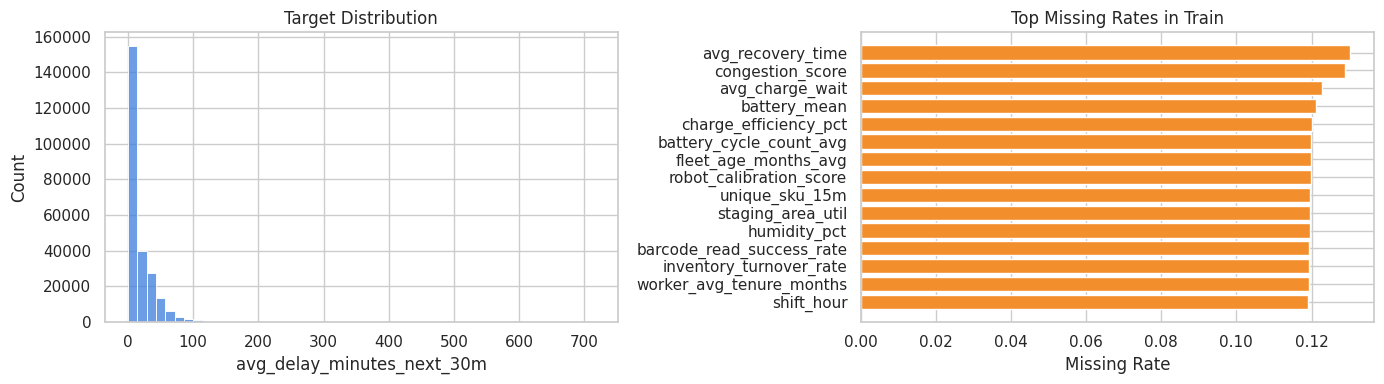

,target_stat
count,250000.000000
mean,18.962296
std,27.351374
min,0.000000
1%,0.000000
5%,1.161278
50%,9.032652
95%,60.792706
99%,120.854721
max,715.858119


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_merged[TARGET_COL], bins=50, ax=axes[0], color='#3b7ddd')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel(TARGET_COL)

top_missing = missing_report.head(15).sort_values('train_missing_rate')
axes[1].barh(top_missing['column'], top_missing['train_missing_rate'], color='#f28e2b')
axes[1].set_title('Top Missing Rates in Train')
axes[1].set_xlabel('Missing Rate')

plt.tight_layout()
plt.show()

target_summary = train_merged[TARGET_COL].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame('target_stat')
target_summary


In [28]:
target_correlations = (
    train_merged[[TARGET_COL] + merged_numeric_cols]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .rename('corr_with_target')
    .to_frame()
)
target_correlations['abs_corr'] = target_correlations['corr_with_target'].abs()
target_correlations = target_correlations.sort_values('abs_corr', ascending=False)

group_target_summary = {
    'day_of_week': train_merged.groupby('day_of_week', dropna=False)[TARGET_COL].agg(['count', 'mean', 'median']).sort_index(),
    'shift_hour': train_merged.groupby('shift_hour', dropna=False)[TARGET_COL].agg(['count', 'mean', 'median']).sort_index(),
    'layout_type': train_merged.groupby('layout_type', dropna=False)[TARGET_COL].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False),
}

target_correlations.head(20)


,corr_with_target,abs_corr
low_battery_ratio,0.366073,0.366073
battery_mean,-0.358886,0.358886
robot_idle,-0.349311,0.349311
order_inflow_15m,0.341754,0.341754
robot_charging,0.320406,0.320406
max_zone_density,0.310816,0.310816
battery_std,0.308313,0.308313
congestion_score,0.300357,0.300357
sku_concentration,0.291888,0.291888
urgent_order_ratio,0.271079,0.271079


In [29]:
group_target_summary['layout_type']


,count,mean,median
layout_type,,,
hub_spoke,43375,22.280032,11.317745
hybrid,73125,18.411890,8.250280
narrow,42250,18.360849,9.467351
grid,91250,18.104791,8.924054


## 전처리 정책표

이 단계는 어떤 컬럼을 유지할지, 어떤 컬럼을 보류할지,
그리고 결측 처리 방향을 어떻게 가져갈지 문서화하는 단계입니다.
아직 모델별 인코딩이나 실제 결측 대체는 수행하지 않습니다.


In [30]:
preprocessing_plan = pd.DataFrame({'column': merged_feature_cols})
preprocessing_plan = preprocessing_plan.merge(missing_report, on='column', how='left')
preprocessing_plan = preprocessing_plan.merge(
    constant_report[['column', 'nunique_non_null', 'top_value_share', 'is_constant', 'is_near_constant']],
    on='column',
    how='left',
)
preprocessing_plan = preprocessing_plan.merge(
    range_violation_report[['column', 'expected_bounds', 'train_out_of_bounds_rate', 'test_out_of_bounds_rate']],
    on='column',
    how='left',
)

def infer_modeling_role(column: str) -> str:
    if column == ID_COL:
        return 'id_only'
    if column == GROUP_COL:
        return 'group_only'
    if column in [LAYOUT_KEY, 'layout_type', 'day_of_week', 'shift_hour']:
        return 'categorical_candidate'
    if column in layout_feature_cols:
        return 'layout_static_numeric'
    return 'numeric_feature'


preprocessing_plan['modeling_role'] = preprocessing_plan['column'].map(infer_modeling_role)
preprocessing_plan['proposed_missing_strategy'] = preprocessing_plan.apply(
    lambda row: propose_missing_strategy(row['column'], row['train_missing_rate']),
    axis=1,
)
preprocessing_plan['use_for_modeling_now'] = ~preprocessing_plan['column'].isin([ID_COL, GROUP_COL])
preprocessing_plan['needs_manual_review'] = (
    preprocessing_plan['is_constant'].fillna(False)
    | preprocessing_plan['is_near_constant'].fillna(False)
    | (preprocessing_plan['train_out_of_bounds_rate'].fillna(0) > 0)
)

preprocessing_plan.sort_values(['needs_manual_review', 'train_missing_rate'], ascending=[False, False]).head(25)


,column,train_missing_rate,test_missing_rate,missing_rate_gap,nunique_non_null,top_value_share,is_constant,is_near_constant,expected_bounds,train_out_of_bounds_rate,test_out_of_bounds_rate,modeling_role,proposed_missing_strategy,use_for_modeling_now,needs_manual_review
26,avg_recovery_time,0.130116,0.13352,0.003404,1383,0.725476,False,False,NaN,NaN,NaN,numeric_feature,median_impute_candidate,True,False
21,congestion_score,0.129000,0.12636,0.002640,4688,0.501716,False,False,NaN,NaN,NaN,numeric_feature,median_impute_candidate,True,False
20,avg_charge_wait,0.122784,0.12398,0.001196,2216,0.717712,False,False,NaN,NaN,NaN,numeric_feature,median_impute_candidate,True,False
16,battery_mean,0.121280,0.12102,0.000260,6813,0.121280,False,False,NaN,NaN,NaN,numeric_feature,review_manually,True,False
73,charge_efficiency_pct,0.120208,0.11630,0.003908,301,0.120208,False,False,"[0.0, 100.0]",0.0,0.0,numeric_feature,missing_indicator_candidate,True,False
74,battery_cycle_count_avg,0.119820,0.12270,0.002880,451,0.119820,False,False,NaN,NaN,NaN,numeric_feature,median_impute_candidate,True,False
69,fleet_age_months_avg,0.119812,0.11854,0.001272,541,0.119812,False,False,NaN,NaN,NaN,numeric_feature,median_impute_candidate,True,False
76,robot_calibration_score,0.119776,0.11766,0.002116,401,0.119776,False,False,NaN,NaN,NaN,numeric_feature,missing_indicator_candidate,True,False
4,unique_sku_15m,0.119696,0.12064,0.000944,501,0.119696,False,False,NaN,NaN,NaN,numeric_feature,review_manually,True,False
66,staging_area_util,0.119568,0.11854,0.001028,9525,0.119568,False,False,"[0.0, 1.0]",0.0,0.0,numeric_feature,missing_indicator_candidate,True,False


## 피처 엔지니어링

아래 파생 피처는 타깃 누수를 피하도록 설계되었습니다.
현재 시점의 행 정보와 정적 레이아웃 메타데이터만 사용하며,
타깃 통계나 `scenario_id` 단위 집계는 사용하지 않습니다.


In [31]:
ENGINEERED_FEATURE_SPECS = [
    {'feature_name': 'observed_robot_pool', 'feature_group': 'robot_state', 'source_columns': 'robot_active, robot_idle, robot_charging', 'description': 'Observed robots active in the snapshot.'},
    {'feature_name': 'robot_active_share_observed', 'feature_group': 'robot_state', 'source_columns': 'robot_active, robot_idle, robot_charging', 'description': 'Share of active robots among observed robots.'},
    {'feature_name': 'robot_idle_share_observed', 'feature_group': 'robot_state', 'source_columns': 'robot_active, robot_idle, robot_charging', 'description': 'Share of idle robots among observed robots.'},
    {'feature_name': 'robot_charging_share_observed', 'feature_group': 'robot_state', 'source_columns': 'robot_active, robot_idle, robot_charging', 'description': 'Share of charging robots among observed robots.'},
    {'feature_name': 'order_inflow_per_observed_robot', 'feature_group': 'capacity_pressure', 'source_columns': 'order_inflow_15m, observed_robot_pool', 'description': 'Recent order inflow normalized by observed robots.'},
    {'feature_name': 'order_inflow_per_layout_robot', 'feature_group': 'capacity_pressure', 'source_columns': 'order_inflow_15m, robot_total', 'description': 'Recent order inflow normalized by layout robot capacity.'},
    {'feature_name': 'unique_sku_per_layout_robot', 'feature_group': 'capacity_pressure', 'source_columns': 'unique_sku_15m, robot_total', 'description': 'SKU complexity per layout robot.'},
    {'feature_name': 'order_inflow_per_pack_station', 'feature_group': 'capacity_pressure', 'source_columns': 'order_inflow_15m, pack_station_count', 'description': 'Recent order inflow normalized by packing stations.'},
    {'feature_name': 'order_inflow_per_charger', 'feature_group': 'capacity_pressure', 'source_columns': 'order_inflow_15m, charger_count', 'description': 'Recent order inflow normalized by charger availability.'},
    {'feature_name': 'staff_per_1000sqm', 'feature_group': 'layout_normalized', 'source_columns': 'staff_on_floor, floor_area_sqm', 'description': 'Workforce density per 1,000 square meters.'},
    {'feature_name': 'robot_density_per_1000sqm', 'feature_group': 'layout_normalized', 'source_columns': 'robot_total, floor_area_sqm', 'description': 'Robot density per 1,000 square meters.'},
    {'feature_name': 'pack_station_density_per_1000sqm', 'feature_group': 'layout_normalized', 'source_columns': 'pack_station_count, floor_area_sqm', 'description': 'Packing station density per 1,000 square meters.'},
    {'feature_name': 'charge_queue_per_charger', 'feature_group': 'battery_stress', 'source_columns': 'charge_queue_length, charger_count', 'description': 'Charging queue normalized by charger count.'},
    {'feature_name': 'low_battery_charge_pressure', 'feature_group': 'battery_stress', 'source_columns': 'low_battery_ratio, charge_queue_length', 'description': 'Joint battery stress indicator.'},
    {'feature_name': 'battery_cv', 'feature_group': 'battery_stress', 'source_columns': 'battery_std, battery_mean', 'description': 'Battery coefficient of variation.'},
    {'feature_name': 'congestion_x_order_inflow', 'feature_group': 'congestion_interaction', 'source_columns': 'congestion_score, order_inflow_15m', 'description': 'Interaction between operational load and congestion.'},
    {'feature_name': 'dock_load_pressure', 'feature_group': 'throughput_interaction', 'source_columns': 'loading_dock_util, order_inflow_15m', 'description': 'Dock usage weighted by recent order inflow.'},
    {'feature_name': 'pack_load_pressure', 'feature_group': 'throughput_interaction', 'source_columns': 'pack_utilization, order_inflow_15m', 'description': 'Packing utilization weighted by recent order inflow.'},
    {'feature_name': 'blocked_paths_per_intersection', 'feature_group': 'congestion_interaction', 'source_columns': 'blocked_path_15m, intersection_count', 'description': 'Blocked paths normalized by layout intersections.'},
    {'feature_name': 'intersection_wait_x_aisle_traffic', 'feature_group': 'congestion_interaction', 'source_columns': 'intersection_wait_time_avg, aisle_traffic_score', 'description': 'Wait pressure under aisle traffic.'},
    {'feature_name': 'prev_shift_volume_per_1000sqm', 'feature_group': 'layout_normalized', 'source_columns': 'prev_shift_volume, floor_area_sqm', 'description': 'Previous shift volume per 1,000 square meters.'},
    {'feature_name': 'storage_x_vertical_pressure', 'feature_group': 'layout_normalized', 'source_columns': 'storage_density_pct, vertical_utilization', 'description': 'Combined static storage pressure indicator.'},
    {'feature_name': 'cold_chain_order_pressure', 'feature_group': 'capacity_pressure', 'source_columns': 'cold_chain_ratio, order_inflow_15m', 'description': 'Cold-chain order pressure.'},
    {'feature_name': 'shift_hour_sin', 'feature_group': 'temporal', 'source_columns': 'shift_hour', 'description': 'Cyclical shift encoding using sine.'},
    {'feature_name': 'shift_hour_cos', 'feature_group': 'temporal', 'source_columns': 'shift_hour', 'description': 'Cyclical shift encoding using cosine.'},
    {'feature_name': 'day_shift_key', 'feature_group': 'temporal', 'source_columns': 'day_of_week, shift_hour', 'description': 'Categorical interaction between day-of-week and shift-hour.'}
]


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    observed_robot_pool = df['robot_active'] + df['robot_idle'] + df['robot_charging']
    df['observed_robot_pool'] = observed_robot_pool
    df['robot_active_share_observed'] = safe_divide(df['robot_active'], observed_robot_pool)
    df['robot_idle_share_observed'] = safe_divide(df['robot_idle'], observed_robot_pool)
    df['robot_charging_share_observed'] = safe_divide(df['robot_charging'], observed_robot_pool)

    df['order_inflow_per_observed_robot'] = safe_divide(df['order_inflow_15m'], df['observed_robot_pool'])
    df['order_inflow_per_layout_robot'] = safe_divide(df['order_inflow_15m'], df['robot_total'])
    df['unique_sku_per_layout_robot'] = safe_divide(df['unique_sku_15m'], df['robot_total'])
    df['order_inflow_per_pack_station'] = safe_divide(df['order_inflow_15m'], df['pack_station_count'])
    df['order_inflow_per_charger'] = safe_divide(df['order_inflow_15m'], df['charger_count'])

    df['staff_per_1000sqm'] = safe_divide(df['staff_on_floor'] * 1000, df['floor_area_sqm'])
    df['robot_density_per_1000sqm'] = safe_divide(df['robot_total'] * 1000, df['floor_area_sqm'])
    df['pack_station_density_per_1000sqm'] = safe_divide(df['pack_station_count'] * 1000, df['floor_area_sqm'])

    df['charge_queue_per_charger'] = safe_divide(df['charge_queue_length'], df['charger_count'])
    df['low_battery_charge_pressure'] = df['low_battery_ratio'] * df['charge_queue_length']
    df['battery_cv'] = safe_divide(df['battery_std'], df['battery_mean'])

    df['congestion_x_order_inflow'] = df['congestion_score'] * df['order_inflow_15m']
    df['dock_load_pressure'] = df['loading_dock_util'] * df['order_inflow_15m']
    df['pack_load_pressure'] = df['pack_utilization'] * df['order_inflow_15m']
    df['blocked_paths_per_intersection'] = safe_divide(df['blocked_path_15m'], df['intersection_count'])
    df['intersection_wait_x_aisle_traffic'] = df['intersection_wait_time_avg'] * df['aisle_traffic_score']

    df['prev_shift_volume_per_1000sqm'] = safe_divide(df['prev_shift_volume'] * 1000, df['floor_area_sqm'])
    df['storage_x_vertical_pressure'] = df['storage_density_pct'] * df['vertical_utilization']
    df['cold_chain_order_pressure'] = df['cold_chain_ratio'] * df['order_inflow_15m']

    shift_hour = pd.to_numeric(df['shift_hour'], errors='coerce')
    df['shift_hour_sin'] = np.sin(2 * np.pi * shift_hour / 24)
    df['shift_hour_cos'] = np.cos(2 * np.pi * shift_hour / 24)
    day_text = pd.to_numeric(df['day_of_week'], errors='coerce').astype('Int64').astype(str)
    shift_text = shift_hour.astype('Int64').astype(str)
    df['day_shift_key'] = 'dow_' + day_text + '__shift_' + shift_text
    return df


train_features = add_engineered_features(train_merged)
test_features = add_engineered_features(test_merged)

engineered_feature_names = [spec['feature_name'] for spec in ENGINEERED_FEATURE_SPECS]
engineered_missing_report = summarize_missing(train_features.drop(columns=[TARGET_COL]), test_features, engineered_feature_names)
feature_summary = pd.DataFrame(ENGINEERED_FEATURE_SPECS).merge(
    engineered_missing_report[['column', 'train_missing_rate', 'test_missing_rate']],
    left_on='feature_name',
    right_on='column',
    how='left',
).drop(columns=['column'])

feature_summary


,feature_name,feature_group,source_columns,description,train_missing_rate,test_missing_rate
0,observed_robot_pool,robot_state,"robot_active, robot_idle, robot_charging",Observed robots active in the snapshot.,0.000000,0.00000
1,robot_active_share_observed,robot_state,"robot_active, robot_idle, robot_charging",Share of active robots among observed robots.,0.000000,0.00000
2,robot_idle_share_observed,robot_state,"robot_active, robot_idle, robot_charging",Share of idle robots among observed robots.,0.000000,0.00000
3,robot_charging_share_observed,robot_state,"robot_active, robot_idle, robot_charging",Share of charging robots among observed robots.,0.000000,0.00000
4,order_inflow_per_observed_robot,capacity_pressure,"order_inflow_15m, observed_robot_pool",Recent order inflow normalized by observed rob...,0.118256,0.11746
5,order_inflow_per_layout_robot,capacity_pressure,"order_inflow_15m, robot_total",Recent order inflow normalized by layout robot...,0.118256,0.11746
6,unique_sku_per_layout_robot,capacity_pressure,"unique_sku_15m, robot_total",SKU complexity per layout robot.,0.119696,0.12064
7,order_inflow_per_pack_station,capacity_pressure,"order_inflow_15m, pack_station_count",Recent order inflow normalized by packing stat...,0.118256,0.11746
8,order_inflow_per_charger,capacity_pressure,"order_inflow_15m, charger_count",Recent order inflow normalized by charger avai...,0.118256,0.11746
9,staff_per_1000sqm,layout_normalized,"staff_on_floor, floor_area_sqm","Workforce density per 1,000 square meters.",0.118352,0.11890


In [32]:
excluded_from_modeling = [ID_COL, GROUP_COL, TARGET_COL]
feature_columns = [col for col in train_features.columns if col not in excluded_from_modeling]

train_target = train_features[TARGET_COL].copy()
train_groups = train_features[GROUP_COL].copy()
train_model_input = train_features[feature_columns].copy()
test_model_input = test_features[feature_columns].copy()

assert list(train_model_input.columns) == list(test_model_input.columns)
assert ID_COL not in train_model_input.columns
assert GROUP_COL not in train_model_input.columns
assert TARGET_COL not in train_model_input.columns
assert TARGET_COL not in test_model_input.columns

categorical_feature_candidates = [
    col for col in [LAYOUT_KEY, 'layout_type', 'day_of_week', 'shift_hour', 'day_shift_key']
    if col in train_model_input.columns
]

final_snapshot = {
    'train_model_input_shape': train_model_input.shape,
    'test_model_input_shape': test_model_input.shape,
    'target_shape': train_target.shape,
    'group_count': int(train_groups.nunique(dropna=True)),
    'engineered_feature_count': len(engineered_feature_names),
    'categorical_feature_candidates': categorical_feature_candidates,
}

final_snapshot


{'train_model_input_shape': (250000, 131),
 'test_model_input_shape': (50000, 131),
 'target_shape': (250000,),
 'group_count': 10000,
 'engineered_feature_count': 26,
 'categorical_feature_candidates': ['layout_id',
  'layout_type',
  'day_of_week',
  'shift_hour',
  'day_shift_key']}

In [33]:
train_model_input.head(3)


,layout_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,robot_active,robot_idle,robot_charging,robot_utilization,avg_trip_distance,task_reassign_15m,battery_mean,battery_std,low_battery_ratio,charge_queue_length,avg_charge_wait,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m,fault_count_15m,avg_recovery_time,replenishment_overlap,pack_utilization,manual_override_ratio,warehouse_temp_avg,humidity_pct,day_of_week,external_temp_c,wind_speed_kmh,precipitation_mm,lighting_level_lux,ambient_noise_db,floor_vibration_idx,return_order_ratio,air_quality_idx,co2_level_ppm,hvac_power_kw,wms_response_time_ms,scanner_error_rate,wifi_signal_db,network_latency_ms,worker_avg_tenure_months,safety_score_monthly,label_print_queue,barcode_read_success_rate,ups_battery_pct,lighting_zone_variance,shift_hour,staff_on_floor,forklift_active_count,loading_dock_util,conveyor_speed_mps,prev_shift_volume,avg_package_weight_kg,inventory_turnover_rate,daily_forecast_accuracy,order_wave_count,pick_list_length_avg,express_lane_util,bulk_order_ratio,staging_area_util,cold_storage_temp_c,pallet_wrap_time_min,fleet_age_months_avg,maintenance_schedule_score,robot_firmware_update_days,avg_idle_duration_min,charge_efficiency_pct,battery_cycle_count_avg,agv_task_success_rate,robot_calibration_score,aisle_traffic_score,zone_temp_variance,path_optimization_score,intersection_wait_time_avg,storage_density_pct,vertical_utilization,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count,observed_robot_pool,robot_active_share_observed,robot_idle_share_observed,robot_charging_share_observed,order_inflow_per_observed_robot,order_inflow_per_layout_robot,unique_sku_per_layout_robot,order_inflow_per_pack_station,order_inflow_per_charger,staff_per_1000sqm,robot_density_per_1000sqm,pack_station_density_per_1000sqm,charge_queue_per_charger,low_battery_charge_pressure,battery_cv,congestion_x_order_inflow,dock_load_pressure,pack_load_pressure,blocked_paths_per_intersection,intersection_wait_x_aisle_traffic,prev_shift_volume_per_1000sqm,storage_x_vertical_pressure,cold_chain_order_pressure,shift_hour_sin,shift_hour_cos,day_shift_key
0,WH_136,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,9,21,0,0.3000,40.22,0.0,70.58,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0867,0.3187,0.0144,NaN,59.1,2.0,-2.8,NaN,26.7,200.0,75.1,0.7036,0.0193,12.2,804.0,NaN,212.0,0.0139,NaN,40.2,84.0,80.9,17.0,0.9409,NaN,0.9346,0.0,18.0,2.0,0.6268,NaN,1462.0,6.72,1.33,0.7206,10.0,5.67,0.1305,0.0994,0.6683,-17.4,6.35,15.5,70.0,38.2,5.15,93.0,201.0,0.9109,94.0,24.4,1.13,77.2,1.51,0.6578,0.4437,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN,hybrid,2.43,27.0,0.1318,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4,30,0.300000,0.700000,0.0,1.700000,1.700000,3.200000,5.1,10.2,3.019628,5.032713,1.677571,0.0,0.0,NaN,0.0,31.9668,16.2537,0.0,36.844,245.260862,0.291866,1.9992,0.000000,1.0,dow_2__shift_0
1,WH_136,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,12,18,0,0.4000,40.96,0.0,69.87,17.6,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.4188,0.0144,19.52,62.7,1.0,NaN,29.1,19.7,217.0,83.3,0.7158,0.0302,24.8,619.0,62.2,229.0,0.0066,-46.9,39.9,64.0,84.1,15.0,0.9135,74.0,1.0000,4.0,NaN,4.0,NaN,1.49,1621.0,10.95,1.51,0.6392,11.0,7.74,0.2778,0.0651,0.5904,-24.5,5.39,21.0,70.1,58.8,3.55,90.8,247.0,NaN,NaN,15.8,NaN,81.5,1.77,0.6707,0.4621,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88,hybrid,2.43,27.0,0.1318,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4,30,0.400000,0.600000,0.0,NaN,NaN,3.100000,NaN,NaN,NaN,5.032713,1.677571,0.0,0.0,0.251896,NaN,NaN,NaN,0.0,27.966,271.934239,0.309930,Na

## 누수 점검 및 다음 단계

- `scenario_id`는 이후 grouped validation을 위한 그룹 키로만 유지하고, 모델 피처에서는 제외합니다.
- 타깃 인코딩, 타깃 집계, 시나리오 단위 집계 피처는 사용하지 않습니다.
- 결측 처리 정책은 먼저 표로 정리하고, 실제 인코딩/대체는 모델링 단계에서 결정합니다.
- 다음 노트북 단계는 `train_model_input`, `test_model_input`, `train_target`, `train_groups`를 시작점으로 사용합니다.


## 산출물 고정 및 Export

이 셀에서는 지금까지 만든 전처리 결과를 노트북 내부 기준의 canonical 산출물로 고정합니다.
핵심 목적은 다음과 같습니다.

- 최종 모델 입력 테이블의 shape와 컬럼 목록 고정
- 범주형/수치형/파생 피처 역할 분리
- 진단 리포트와 정책표를 파일로 저장
- 필요 시 모델 입력과 타깃/그룹 벡터까지 export


In [36]:
artifact_output_dir = REPO_ROOT / 'artifacts' / 'pre_model'
artifact_output_dir.mkdir(parents=True, exist_ok=True)

raw_table_summary = pd.DataFrame(
    [
        {'table': 'train', 'rows': len(train), 'cols': train.shape[1]},
        {'table': 'test', 'rows': len(test), 'cols': test.shape[1]},
        {'table': 'layout_info', 'rows': len(layout_info), 'cols': layout_info.shape[1]},
        {'table': 'sample_submission', 'rows': len(sample_submission), 'cols': sample_submission.shape[1]},
    ]
)

model_input_missing_summary = summarize_missing(train_model_input, test_model_input, list(train_model_input.columns))
engineered_feature_names = {spec['feature_name'] for spec in ENGINEERED_FEATURE_SPECS}
missing_map = model_input_missing_summary.set_index('column')
feature_role_rows = []

for column in train_model_input.columns:
    if column in [LAYOUT_KEY, 'layout_type', 'day_of_week', 'shift_hour', 'day_shift_key']:
        feature_kind = 'categorical'
    elif pd.api.types.is_numeric_dtype(train_model_input[column]):
        feature_kind = 'numeric'
    else:
        feature_kind = 'categorical'

    if column in engineered_feature_names:
        feature_origin = 'engineered'
    elif column in layout_feature_cols:
        feature_origin = 'layout_static'
    else:
        feature_origin = 'raw_dynamic'

    feature_role_rows.append(
        {
            'column': column,
            'feature_kind': feature_kind,
            'feature_origin': feature_origin,
            'train_dtype': str(train_model_input[column].dtype),
            'test_dtype': str(test_model_input[column].dtype),
            'train_missing_rate': float(missing_map.loc[column, 'train_missing_rate']),
            'test_missing_rate': float(missing_map.loc[column, 'test_missing_rate']),
        }
    )

feature_roles = pd.DataFrame(feature_role_rows).sort_values(['feature_kind', 'feature_origin', 'column']).reset_index(drop=True)
categorical_feature_columns = feature_roles.loc[feature_roles['feature_kind'] == 'categorical', 'column'].tolist()
numeric_feature_columns = feature_roles.loc[feature_roles['feature_kind'] == 'numeric', 'column'].tolist()

feature_manifest = {
    'generated_at_utc': pd.Timestamp.utcnow().isoformat(),
    'source_notebook': 'src/first_src_pre_model.ipynb',
    'canonical_implementation': 'notebook_only',
    'canonical_pre_imputation_state': True,
    'train_model_input_shape': list(train_model_input.shape),
    'test_model_input_shape': list(test_model_input.shape),
    'train_target_shape': [int(train_target.shape[0])],
    'train_groups_shape': [int(train_groups.shape[0])],
    'feature_count': len(train_model_input.columns),
    'engineered_feature_count': len(ENGINEERED_FEATURE_SPECS),
    'categorical_feature_count': len(categorical_feature_columns),
    'numeric_feature_count': len(numeric_feature_columns),
    'group_count': int(train_groups.nunique(dropna=True)),
    'categorical_features': categorical_feature_columns,
    'numeric_features': numeric_feature_columns,
    'all_feature_columns': list(train_model_input.columns),
}

artifact_readme = f'''# Pre-Model Notebook Snapshot

단일 노트북 파일 `src/first_src_pre_model.ipynb`에서 생성한 전처리/진단 산출물 요약입니다.

## Snapshot
- Generated at (UTC): `{feature_manifest['generated_at_utc']}`
- Source notebook: `{feature_manifest['source_notebook']}`
- Canonical implementation: `{feature_manifest['canonical_implementation']}`
- `train_model_input`: `{tuple(feature_manifest['train_model_input_shape'])}`
- `test_model_input`: `{tuple(feature_manifest['test_model_input_shape'])}`
- `train_target`: `{tuple(feature_manifest['train_target_shape'])}`
- `train_groups`: `{tuple(feature_manifest['train_groups_shape'])}`
- Total feature count: `{feature_manifest['feature_count']}`
- Categorical feature count: `{feature_manifest['categorical_feature_count']}`
- Numeric feature count: `{feature_manifest['numeric_feature_count']}`
- Group count: `{feature_manifest['group_count']}`

## Canonical Decision
- 최종 모델 입력은 pre-imputation 상태로 고정합니다.
- `scenario_id`는 grouped validation 용도로만 유지하고 모델 피처에서는 제외합니다.
- 파생 피처는 현재 시점 정보와 정적 레이아웃 정보만 사용합니다.

## Files
- `{artifact_output_dir / 'feature_manifest.json'}`
- `{artifact_output_dir / 'feature_roles.csv'}`
- `{artifact_output_dir / 'preprocessing_plan.csv'}`
- `{artifact_output_dir / 'target_correlations.csv'}`
- `{artifact_output_dir / 'pre_imputation_missing_summary.csv'}`
- `{artifact_output_dir / 'train_model_input_pre_imputation.csv.gz'}`
- `{artifact_output_dir / 'test_model_input_pre_imputation.csv.gz'}`
- `{artifact_output_dir / 'train_target.csv.gz'}`
- `{artifact_output_dir / 'train_groups.csv.gz'}`
'''

raw_table_summary.to_csv(artifact_output_dir / 'raw_table_summary.csv', index=False)
column_role_summary.to_csv(artifact_output_dir / 'column_role_summary.csv', index=False)
key_cardinality.rename_axis('metric').reset_index().to_csv(artifact_output_dir / 'key_cardinality.csv', index=False)
layout_coverage_summary.to_csv(artifact_output_dir / 'layout_coverage_summary.csv', index=False)
missing_report.to_csv(artifact_output_dir / 'pre_imputation_missing_summary.csv', index=False)
constant_report.to_csv(artifact_output_dir / 'constant_report.csv', index=False)
range_violation_report.to_csv(artifact_output_dir / 'range_violation_report.csv', index=False)
outlier_report.to_csv(artifact_output_dir / 'outlier_report.csv', index=False)
shift_report.to_csv(artifact_output_dir / 'shift_report.csv', index=False)
target_summary.to_csv(artifact_output_dir / 'target_summary.csv')
target_correlations.to_csv(artifact_output_dir / 'target_correlations.csv')
for group_name, group_df in group_target_summary.items():
    group_df.to_csv(artifact_output_dir / f'group_target_summary_{group_name}.csv')
preprocessing_plan.to_csv(artifact_output_dir / 'preprocessing_plan.csv', index=False)
feature_summary.to_csv(artifact_output_dir / 'feature_summary.csv', index=False)
feature_roles.to_csv(artifact_output_dir / 'feature_roles.csv', index=False)
(artifact_output_dir / 'feature_manifest.json').write_text(json.dumps(feature_manifest, indent=2), encoding='utf-8')
(artifact_output_dir / 'diagnostic_snapshot.json').write_text(json.dumps(diagnostic_snapshot, indent=2), encoding='utf-8')
(artifact_output_dir / 'README.md').write_text(artifact_readme, encoding='utf-8')

train_model_input.to_csv(artifact_output_dir / 'train_model_input_pre_imputation.csv.gz', index=False, compression='gzip')
test_model_input.to_csv(artifact_output_dir / 'test_model_input_pre_imputation.csv.gz', index=False, compression='gzip')
train_target.to_frame(TARGET_COL).to_csv(artifact_output_dir / 'train_target.csv.gz', index=False, compression='gzip')
train_groups.to_frame(GROUP_COL).to_csv(artifact_output_dir / 'train_groups.csv.gz', index=False, compression='gzip')

feature_manifest


{'generated_at_utc': '2026-04-17T05:49:50.266185+00:00',
 'source_notebook': 'src/first_src_pre_model.ipynb',
 'canonical_implementation': 'notebook_only',
 'canonical_pre_imputation_state': True,
 'train_model_input_shape': [250000, 131],
 'test_model_input_shape': [50000, 131],
 'train_target_shape': [250000],
 'train_groups_shape': [250000],
 'feature_count': 131,
 'engineered_feature_count': 26,
 'categorical_feature_count': 5,
 'numeric_feature_count': 126,
 'group_count': 10000,
 'categorical_features': ['day_shift_key',
  'layout_type',
  'day_of_week',
  'layout_id',
  'shift_hour'],
 'numeric_features': ['battery_cv',
  'blocked_paths_per_intersection',
  'charge_queue_per_charger',
  'cold_chain_order_pressure',
  'congestion_x_order_inflow',
  'dock_load_pressure',
  'intersection_wait_x_aisle_traffic',
  'low_battery_charge_pressure',
  'observed_robot_pool',
  'order_inflow_per_charger',
  'order_inflow_per_layout_robot',
  'order_inflow_per_observed_robot',
  'order_inflo